In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec 
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway
from matplotlib import cm
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable



import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,calculate_relative_distance_goal_ts
#from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa
from pipeline.gaze_shift_functions import *
from pipeline.oa_with_cams_plotting_funcs import *
np.set_printoptions(suppress=True)

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [12]:
def plot_clipped_histogram(npz_path, cmap='viridis', clip_percentile=95):
    data = np.load(npz_path)
    hist = data['hist']
    xedges = data['xedges']
    yedges = data['yedges']
    
    # Determine clipping threshold
    clip_value = np.percentile(hist, clip_percentile)
    
    plt.pcolormesh(xedges, yedges, np.clip(hist.T, 0, clip_value), 
                   cmap=cmap, shading='auto')
    plt.colorbar(label=f'Counts (clipped at {clip_percentile}%)')
    plt.xlabel('Distance from edge')
    plt.ylabel('Eye/Head rotation ratio')
    plt.title(f'Clipped (P{clip_percentile}) Gaze Distance-Ratio')
    plt.show()

In [2]:
F3LILT_050725_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\cluster_F3LILT_050725_oa.h5")
F3LILT_050725_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LILT_050725_df)
ts_calculate_relative_distance(F3LILT_050725_df)
calculate_relative_distance_goal(F3LILT_050725_df)
calculate_relative_distance_goal_ts(F3LILT_050725_df)
calculate_speed(F3LILT_050725_df)
create_gaze_pdf_report(df=F3LILT_050725_df, imu_data=F3LILT_050725_imu, output_filename='F3LILT_050725_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\F3LILT_050725_df_new_gaze_report.pdf


In [5]:
create_gaze_pdf_report(df=F3LILT_050725_df, imu_data=F3LILT_050725_imu, output_filename='F3LILT_050725_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\F3LILT_050725_df_new_gaze_report.pdf


In [11]:
process_and_save_gaze_histogram(F3LILT_050725_df, F3LILT_050725_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam", filename='F3LILT_050725_gaze_distance_ratio_histogram.npz')

'\\\\goeppert\\Vol2\\mike\\recordings\\050725\\F3LILT\\oa_cam\\F3LILT_050725_gaze_distance_ratio_histogram.npz'

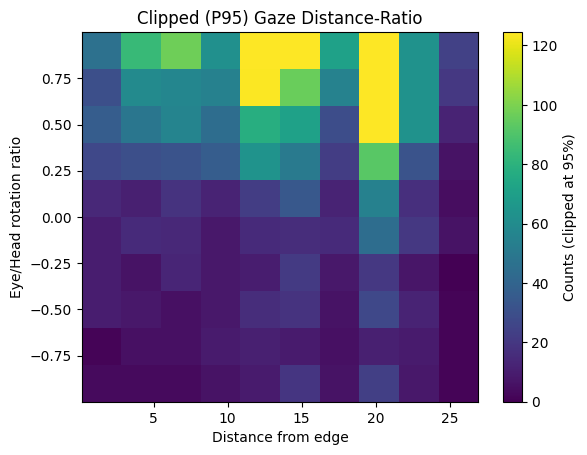

In [15]:
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\F3LILT_050725_gaze_distance_ratio_histogram.npz")

In [17]:
process_and_save_gaze_histogram(F3LILT_050725_df, F3LILT_050725_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam", 
                                filename='F3LILT_050725_gaze_distance_port_ratio_histogram.npz')

'\\\\goeppert\\Vol2\\mike\\recordings\\050725\\F3LILT\\oa_cam\\F3LILT_050725_gaze_distance_port_ratio_histogram.npz'

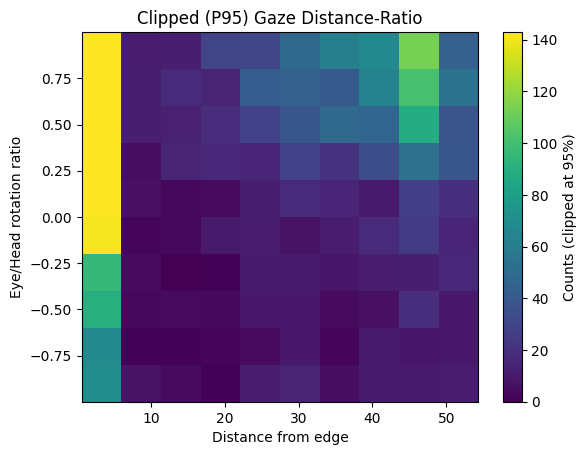

In [18]:
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\F3LILT_050725_gaze_distance_port_ratio_histogram.npz", clip_percentile=95)

In [19]:
F3LILT_050825_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\cluster_F3LILT_050825_oa.h5")
F3LILT_050825_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LILT_050825_df)
ts_calculate_relative_distance(F3LILT_050825_df)
calculate_relative_distance_goal(F3LILT_050825_df)
calculate_relative_distance_goal_ts(F3LILT_050825_df)
calculate_speed(F3LILT_050825_df)
create_gaze_pdf_report(df=F3LILT_050825_df, imu_data=F3LILT_050825_imu, output_filename='F3LILT_050825_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\F3LILT_050825_df_new_gaze_report.pdf


In [20]:
process_and_save_gaze_histogram(F3LILT_050825_df, F3LILT_050825_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1", filename='F3LILT_050825_gaze_distance_ratio_histogram.npz')

'\\\\goeppert\\Vol2\\mike\\recordings\\050825\\F3LILT\\oa_cam1\\F3LILT_050825_gaze_distance_ratio_histogram.npz'

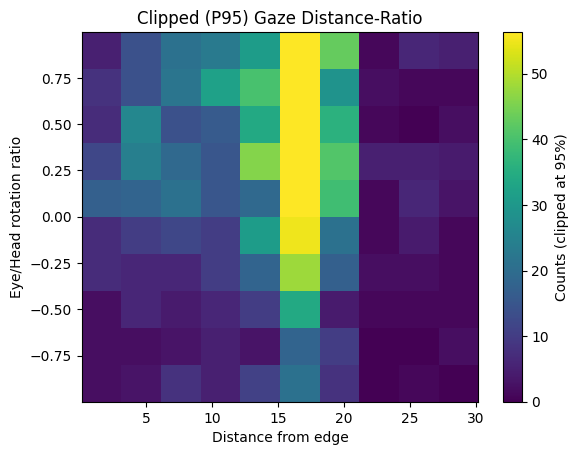

In [21]:
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\F3LILT_050825_gaze_distance_ratio_histogram.npz")

In [22]:
process_and_save_gaze_histogram(F3LILT_050825_df, F3LILT_050825_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1", 
                                filename='F3LILT_050825_gaze_distance_port_ratio_histogram.npz')

'\\\\goeppert\\Vol2\\mike\\recordings\\050825\\F3LILT\\oa_cam1\\F3LILT_050825_gaze_distance_port_ratio_histogram.npz'

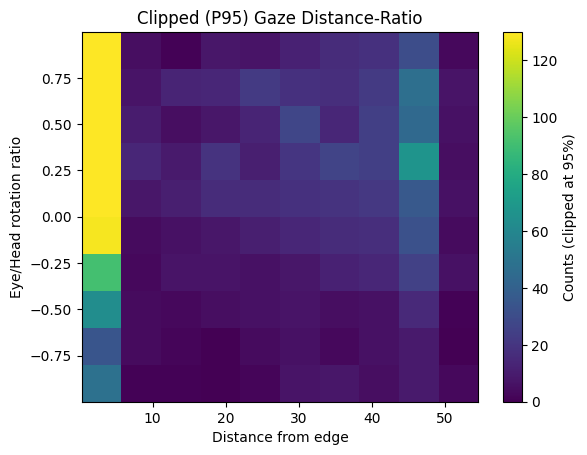

In [23]:
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\F3LILT_050825_gaze_distance_port_ratio_histogram.npz", clip_percentile=95)

In [24]:
F3LILT_050925_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam\cluster_F3LILT_050925_oa.h5")
F3LILT_050925_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam\050925_F3LILT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LILT_050925_df)
ts_calculate_relative_distance(F3LILT_050925_df)
calculate_relative_distance_goal(F3LILT_050925_df)
calculate_relative_distance_goal_ts(F3LILT_050925_df)
calculate_speed(F3LILT_050925_df)
create_gaze_pdf_report(df=F3LILT_050925_df, imu_data=F3LILT_050925_imu, output_filename='F3LILT_050925_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam\F3LILT_050925_df_new_gaze_report.pdf


In [25]:
process_and_save_gaze_histogram(F3LILT_050925_df, F3LILT_050925_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam", filename='F3LILT_050925_gaze_distance_ratio_histogram.npz')

'\\\\goeppert\\Vol2\\mike\\recordings\\050925\\F3LILT\\oa_cam\\F3LILT_050925_gaze_distance_ratio_histogram.npz'

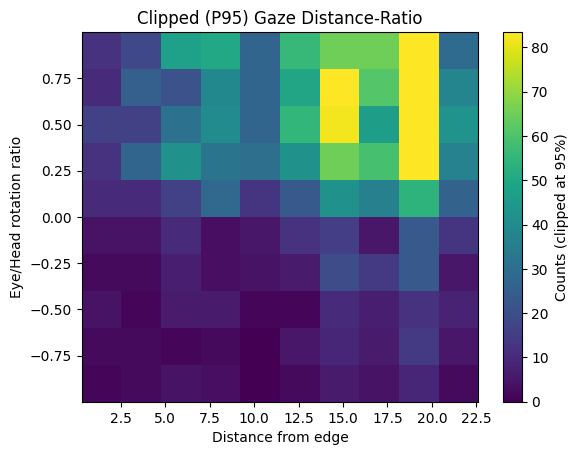

In [26]:
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam\F3LILT_050925_gaze_distance_ratio_histogram.npz")

In [27]:
process_and_save_gaze_histogram(F3LILT_050925_df, F3LILT_050925_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam", 
                                filename='F3LILT_050925_gaze_distance_port_ratio_histogram.npz')

'\\\\goeppert\\Vol2\\mike\\recordings\\050925\\F3LILT\\oa_cam\\F3LILT_050925_gaze_distance_port_ratio_histogram.npz'

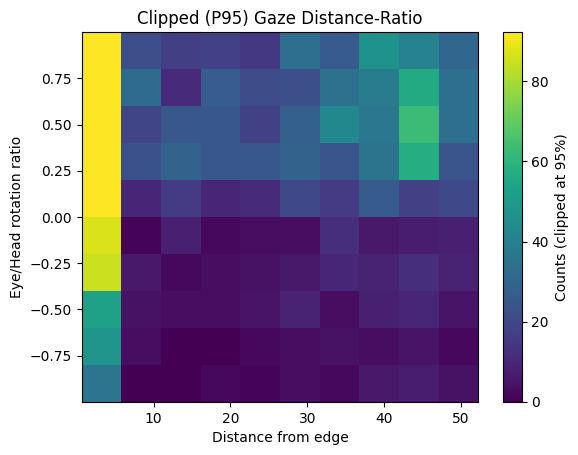

In [28]:
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam\F3LILT_050925_gaze_distance_port_ratio_histogram.npz", clip_percentile=95)

In [30]:
F3LILT_051225_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\cluster_F3LILT_051225_oa.h5")
F3LILT_051225_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LILT_051225_df)
ts_calculate_relative_distance(F3LILT_051225_df)
calculate_relative_distance_goal(F3LILT_051225_df)
calculate_relative_distance_goal_ts(F3LILT_051225_df)
calculate_speed(F3LILT_051225_df)
create_gaze_pdf_report(df=F3LILT_051225_df, imu_data=F3LILT_051225_imu, output_filename='F3LILT_051225_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_df_new_gaze_report.pdf


In [31]:
process_and_save_gaze_histogram(F3LILT_051225_df, F3LILT_051225_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam", filename='F3LILT_051225_gaze_distance_ratio_histogram.npz')

'\\\\goeppert\\Vol2\\mike\\recordings\\051225\\F3LILT\\oa_cam\\F3LILT_051225_gaze_distance_ratio_histogram.npz'

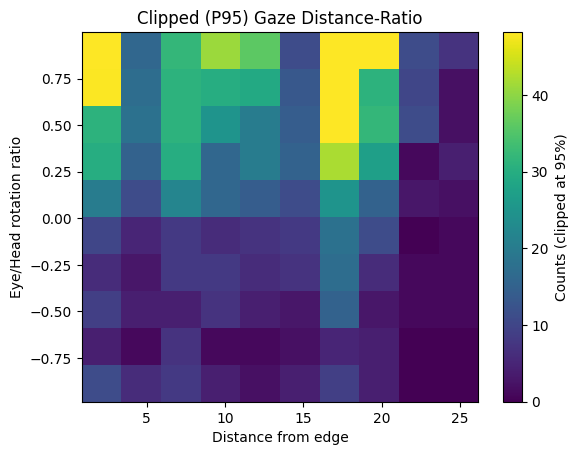

In [32]:
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_gaze_distance_ratio_histogram.npz")

In [33]:
process_and_save_gaze_histogram(F3LILT_051225_df, F3LILT_051225_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam", 
                                filename='F3LILT_051225_gaze_distance_port_ratio_histogram.npz')

'\\\\goeppert\\Vol2\\mike\\recordings\\051225\\F3LILT\\oa_cam\\F3LILT_051225_gaze_distance_port_ratio_histogram.npz'

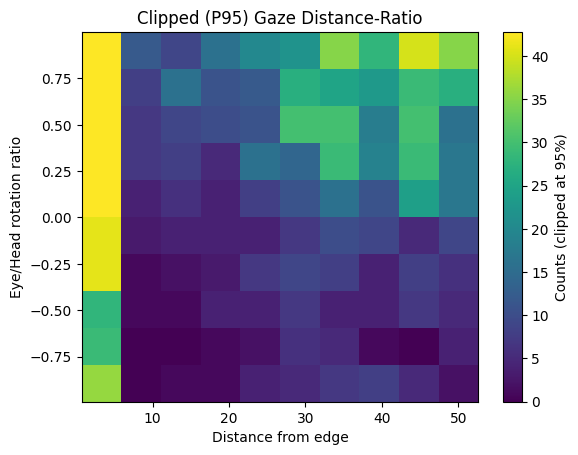

In [34]:
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_gaze_distance_port_ratio_histogram.npz", clip_percentile=95)

In [35]:
F3LILT_051325_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\cluster_F3LILT_051325_oa.h5")
F3LILT_051325_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\051325_F3LILT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LILT_051325_df)
ts_calculate_relative_distance(F3LILT_051325_df)
calculate_relative_distance_goal(F3LILT_051325_df)
calculate_relative_distance_goal_ts(F3LILT_051325_df)
calculate_speed(F3LILT_051325_df)
create_gaze_pdf_report(df=F3LILT_051325_df, imu_data=F3LILT_051325_imu, output_filename='F3LILT_051325_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\F3LILT_051325_df_new_gaze_report.pdf


In [ ]:
process_and_save_gaze_histogram(F3LILT_051325_df, F3LILT_051325_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam", filename='F3LILT_051325_gaze_distance_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\F3LILT_051325_gaze_distance_ratio_histogram.npz")

'\\\\goeppert\\Vol2\\mike\\recordings\\051325\\F3LILT\\oa_cam\\F3LILT_051325_gaze_distance_ratio_histogram.npz'

In [ ]:
process_and_save_gaze_histogram(F3LILT_051325_df, F3LILT_051325_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam", 
                                filename='F3LILT_051325_gaze_distance_port_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\F3LILT_051325_gaze_distance_port_ratio_histogram.npz", clip_percentile=95)

'\\\\goeppert\\Vol2\\mike\\recordings\\051325\\F3LILT\\oa_cam\\F3LILT_051325_gaze_distance_port_ratio_histogram.npz'

In [88]:
F3LITT_050725_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\cluster_F3LITT_050725_oa.h5")
F3LITT_050725_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\050725_F3LITT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LITT_050725_df)
ts_calculate_relative_distance(F3LITT_050725_df)
calculate_relative_distance_goal(F3LITT_050725_df)
calculate_relative_distance_goal_ts(F3LITT_050725_df)
calculate_speed(F3LITT_050725_df)
create_gaze_pdf_report(df=F3LITT_050725_df, imu_data=F3LITT_050725_imu, output_filename='F3LITT_050725_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\F3LITT_050725_df_new_gaze_report.pdf


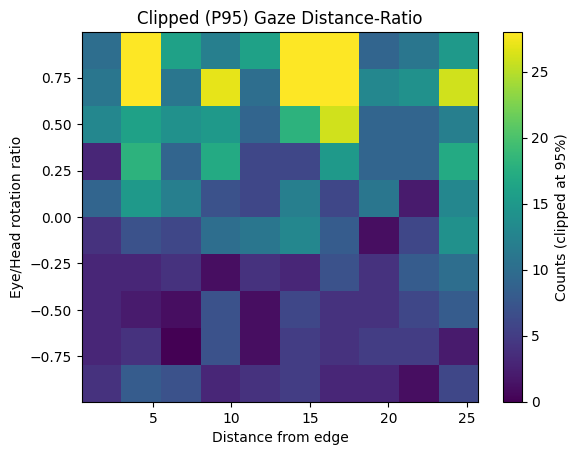

In [89]:
process_and_save_gaze_histogram(F3LITT_050725_df, F3LITT_050725_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam", filename='F3LITT_050725_gaze_distance_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\F3LITT_050725_gaze_distance_ratio_histogram.npz")

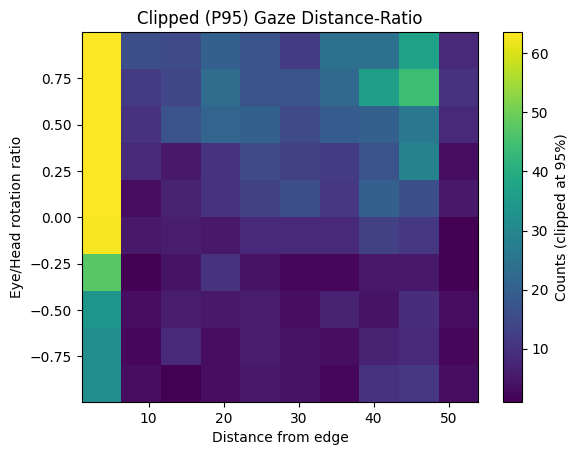

In [90]:
process_and_save_gaze_histogram(F3LITT_050725_df, F3LITT_050725_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam", 
                                filename='F3LITT_050725_gaze_distance_port_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\F3LITT_050725_gaze_distance_port_ratio_histogram.npz", clip_percentile=95)

In [40]:
F3LITT_050825_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam\cluster_F3LITT_050825_oa.h5")
F3LITT_050825_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam\050825_F3LITT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LITT_050825_df)
ts_calculate_relative_distance(F3LITT_050825_df)
calculate_relative_distance_goal(F3LITT_050825_df)
calculate_relative_distance_goal_ts(F3LITT_050825_df)
calculate_speed(F3LITT_050825_df)
create_gaze_pdf_report(df=F3LITT_050825_df, imu_data=F3LITT_050825_imu, output_filename='F3LITT_050825_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam\F3LITT_050825_df_new_gaze_report.pdf


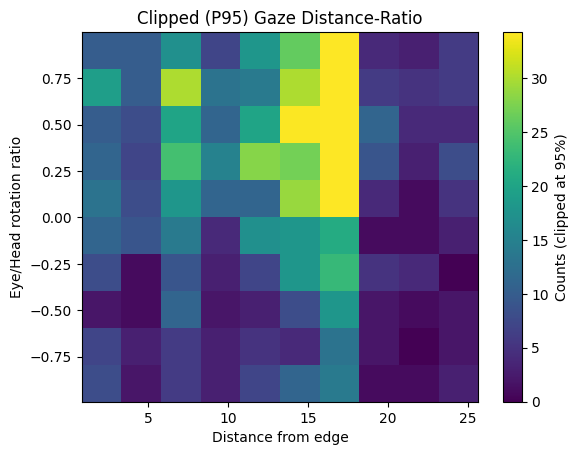

In [41]:
process_and_save_gaze_histogram(F3LITT_050825_df, F3LITT_050825_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam", filename='F3LITT_050825_gaze_distance_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam\F3LITT_050825_gaze_distance_ratio_histogram.npz")

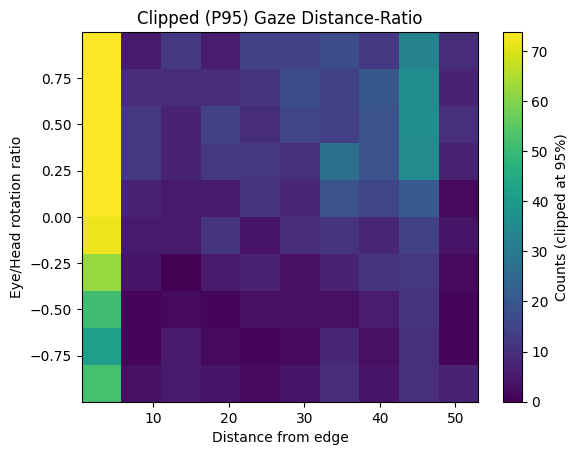

In [42]:
process_and_save_gaze_histogram(F3LITT_050825_df, F3LITT_050825_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam", 
                                filename='F3LITT_050825_gaze_distance_port_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam\F3LITT_050825_gaze_distance_port_ratio_histogram.npz", clip_percentile=95)

In [43]:
F3LITT_050925_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam\cluster_F3LITT_050925_oa.h5")
F3LITT_050925_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam\050925_F3LITT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LITT_050925_df)
ts_calculate_relative_distance(F3LITT_050925_df)
calculate_relative_distance_goal(F3LITT_050925_df)
calculate_relative_distance_goal_ts(F3LITT_050925_df)
calculate_speed(F3LITT_050925_df)
create_gaze_pdf_report(df=F3LITT_050925_df, imu_data=F3LITT_050925_imu, output_filename='F3LITT_050925_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam\F3LITT_050925_df_new_gaze_report.pdf


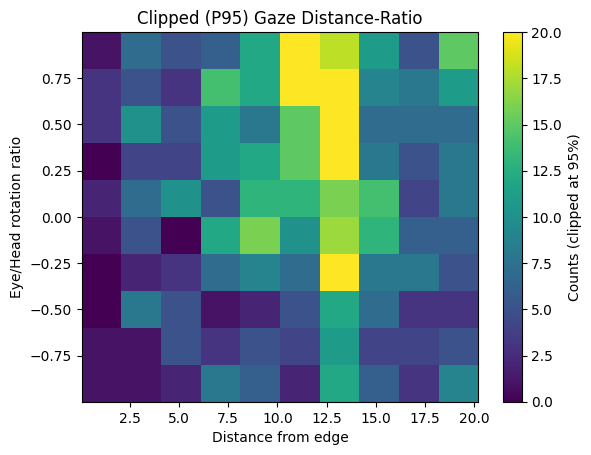

In [44]:
process_and_save_gaze_histogram(F3LITT_050925_df, F3LITT_050925_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam", filename='F3LITT_050925_gaze_distance_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam\F3LITT_050925_gaze_distance_ratio_histogram.npz")

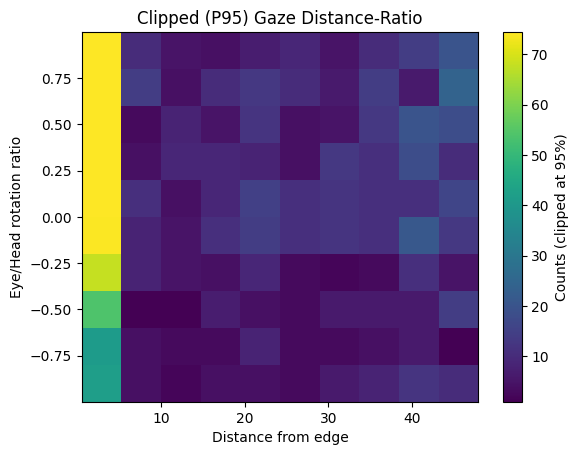

In [45]:
process_and_save_gaze_histogram(F3LITT_050925_df, F3LITT_050925_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam", 
                                filename='F3LITT_050925_gaze_distance_port_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam\F3LITT_050925_gaze_distance_port_ratio_histogram.npz", clip_percentile=95)

In [46]:
F3LITT_051225_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\cluster_F3LITT_051225_oa.h5")
F3LITT_051225_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LITT_051225_df)
ts_calculate_relative_distance(F3LITT_051225_df)
calculate_relative_distance_goal(F3LITT_051225_df)
calculate_relative_distance_goal_ts(F3LITT_051225_df)
calculate_speed(F3LITT_051225_df)
create_gaze_pdf_report(df=F3LITT_051225_df, imu_data=F3LITT_051225_imu, output_filename='F3LITT_051225_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\F3LITT_051225_df_new_gaze_report.pdf


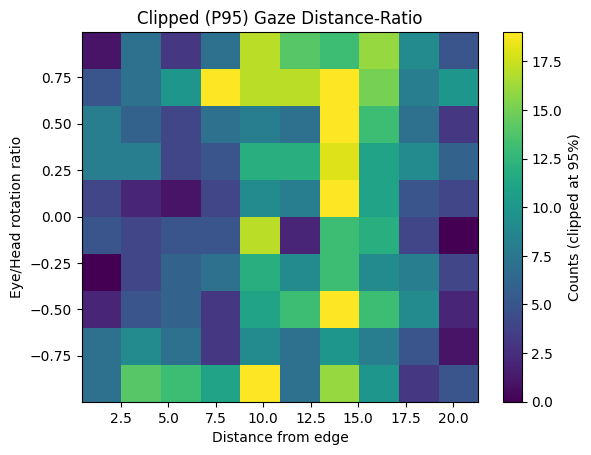

In [47]:
process_and_save_gaze_histogram(F3LITT_051225_df, F3LITT_051225_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam", filename='F3LITT_051225_gaze_distance_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\F3LITT_051225_gaze_distance_ratio_histogram.npz")

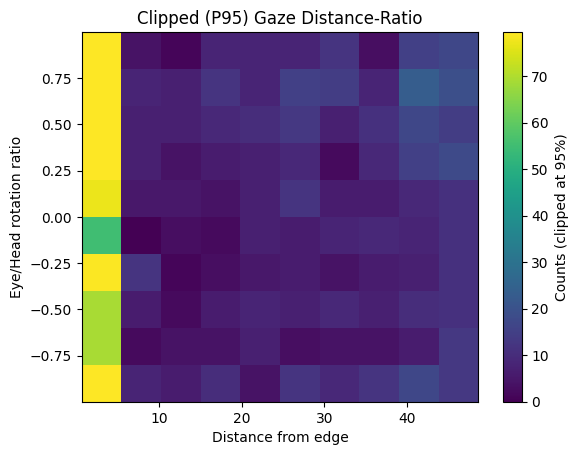

In [48]:
process_and_save_gaze_histogram(F3LITT_051225_df, F3LITT_051225_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam", 
                                filename='F3LITT_051225_gaze_distance_port_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\F3LITT_051225_gaze_distance_port_ratio_histogram.npz", clip_percentile=95)

In [49]:
F3LITT_051325_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\cluster_F3LITT_051325_oa.h5")
F3LITT_051325_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\051325_F3LITT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LITT_051325_df)
ts_calculate_relative_distance(F3LITT_051325_df)
calculate_relative_distance_goal(F3LITT_051325_df)
calculate_relative_distance_goal_ts(F3LITT_051325_df)
calculate_speed(F3LITT_051325_df)
create_gaze_pdf_report(df=F3LITT_051325_df, imu_data=F3LITT_051325_imu, output_filename='F3LITT_051325_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\F3LITT_051325_df_new_gaze_report.pdf


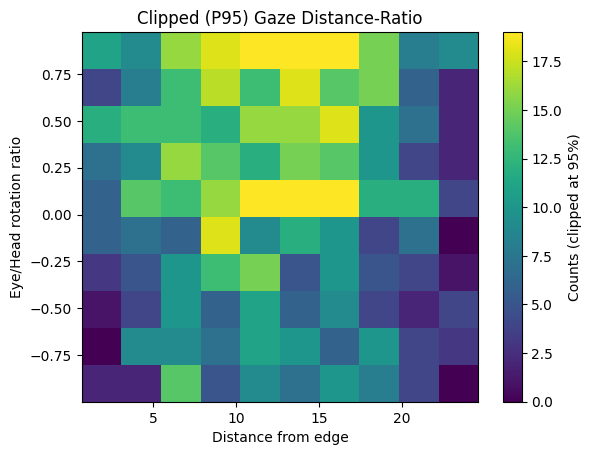

In [50]:
process_and_save_gaze_histogram(F3LITT_051325_df, F3LITT_051325_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam", filename='F3LITT_051325_gaze_distance_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\F3LITT_051325_gaze_distance_ratio_histogram.npz")

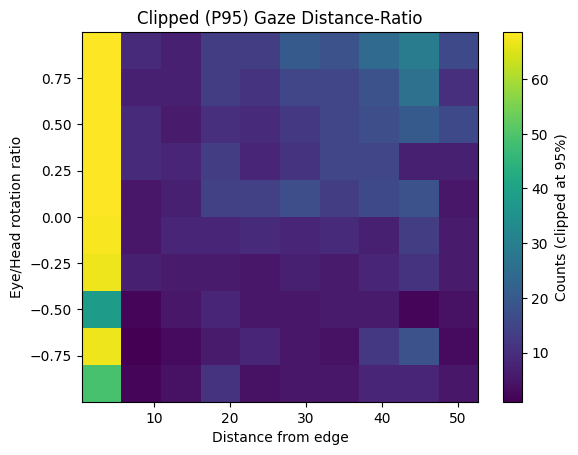

In [51]:
process_and_save_gaze_histogram(F3LITT_051325_df, F3LITT_051325_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam", 
                                filename='F3LITT_051325_gaze_distance_port_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\F3LITT_051325_gaze_distance_port_ratio_histogram.npz", clip_percentile=95)

In [52]:
J731_050725_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam\cluster_J731_050725_oa.h5")
J731_050725_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam\050725_J731_imu_eyecam_dict.npz")
calculate_relative_distance(J731_050725_df)
ts_calculate_relative_distance(J731_050725_df)
calculate_relative_distance_goal(J731_050725_df)
calculate_relative_distance_goal_ts(J731_050725_df)
calculate_speed(J731_050725_df)
create_gaze_pdf_report(df=J731_050725_df, imu_data=J731_050725_imu, output_filename='J731_050725_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\050725\J731\oa_cam\J731_050725_df_new_gaze_report.pdf


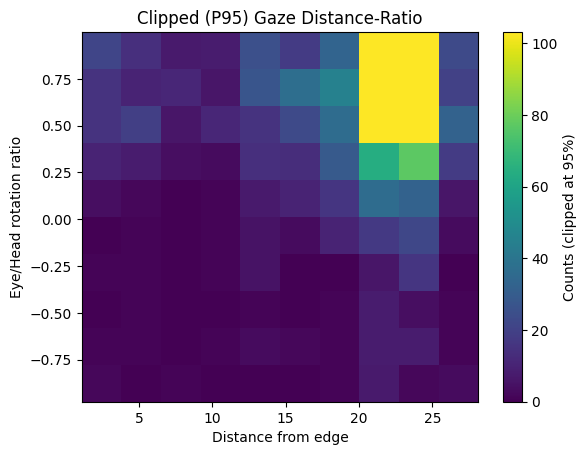

In [53]:
process_and_save_gaze_histogram(J731_050725_df, J731_050725_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam", filename='J731_050725_gaze_distance_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam\J731_050725_gaze_distance_ratio_histogram.npz")

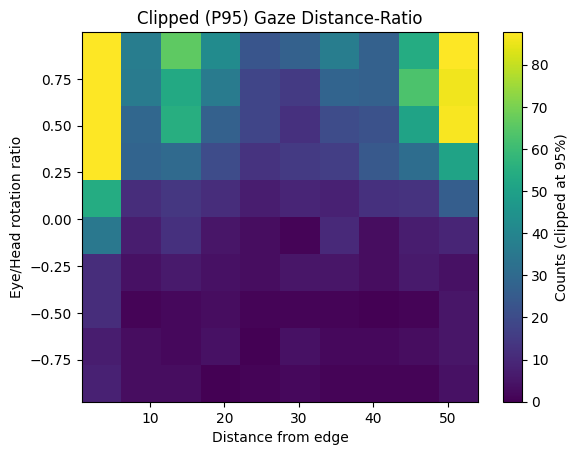

In [55]:
process_and_save_gaze_histogram(J731_050725_df, J731_050725_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam", 
                                filename='J731_050725_gaze_distance_port_ratio_histogram.npz')
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\050725\J731\oa_cam\J731_050725_gaze_distance_port_ratio_histogram.npz", clip_percentile=95)

In [56]:
J731_050825_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\cluster_J731_050825_oa.h5")
J731_050825_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\050825_J731_imu_eyecam_dict.npz")
calculate_relative_distance(J731_050825_df)
ts_calculate_relative_distance(J731_050825_df)
calculate_relative_distance_goal(J731_050825_df)
calculate_relative_distance_goal_ts(J731_050825_df)
calculate_speed(J731_050825_df)
create_gaze_pdf_report(df=J731_050825_df, imu_data=J731_050825_imu, output_filename='J731_050825_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\050825\J731\oa_cam1\J731_050825_df_new_gaze_report.pdf


In [57]:
J731_050925_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\050925\J731\oa_cam\cluster_J731_050925_oa.h5")
J731_050925_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050925\J731\oa_cam\050925_J731_imu_eyecam_dict.npz")
calculate_relative_distance(J731_050925_df)
ts_calculate_relative_distance(J731_050925_df)
calculate_relative_distance_goal(J731_050925_df)
calculate_relative_distance_goal_ts(J731_050925_df)
calculate_speed(J731_050925_df)
create_gaze_pdf_report(df=J731_050925_df, imu_data=J731_050925_imu, output_filename='J731_050925_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\050925\J731\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\050925\J731\oa_cam\J731_050925_df_new_gaze_report.pdf


In [58]:
J731_051225_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051225\J731\oa_cam\cluster_J731_051225_oa.h5")
J731_051225_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051225\J731\oa_cam\051225_J731_imu_eyecam_dict.npz")
calculate_relative_distance(J731_051225_df)
ts_calculate_relative_distance(J731_051225_df)
calculate_relative_distance_goal(J731_051225_df)
calculate_relative_distance_goal_ts(J731_051225_df)
calculate_speed(J731_051225_df)
create_gaze_pdf_report(df=J731_051225_df, imu_data=J731_051225_imu, output_filename='J731_051225_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\051225\J731\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\051225\J731\oa_cam\J731_051225_df_new_gaze_report.pdf


In [ ]:
F3LILT_050725 = np.load(r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\F3LILT_050725_gaze_distance_ratio_histogram.npz")
F3LILT_050825 = np.load(r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\F3LILT_050825_gaze_distance_ratio_histogram.npz")
F3LILT_050925 = np.load(r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam\F3LILT_050925_gaze_distance_ratio_histogram.npz")
F3LILT_051225 = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_gaze_distance_ratio_histogram.npz")
F3LILT_051325 = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\F3LILT_051325_gaze_distance_ratio_histogram.npz")

F3LITT_050725 = np.load(r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\F3LITT_050725_gaze_distance_ratio_histogram.npz")
F3LITT_050825 = np.load(r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam\F3LITT_050825_gaze_distance_ratio_histogram.npz")
F3LITT_050925 = np.load(r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam\F3LITT_050925_gaze_distance_ratio_histogram.npz")
F3LITT_051225 = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\F3LITT_051225_gaze_distance_ratio_histogram.npz")
F3LITT_051325 = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\F3LITT_051325_gaze_distance_ratio_histogram.npz")


In [ ]:
F3LILT_051325 = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\F3LILT_051325_gaze_distance_ratio_histogram.npz")

In [ ]:
F3LILT_gaze_ratio_hist = F3LILT_050725['hist']+ F3LILT_050825['hist']+ F3LILT_050925['hist']+ F3LILT_051225['hist']+ F3LILT_051325['hist']
F3LITT_gaze_ratio_hist = F3LITT_050725['hist']+ F3LITT_050825['hist']+ F3LITT_050925['hist']+ F3LITT_051225['hist']+ F3LITT_051325['hist']

In [76]:
np.nanmean([F3LILT_050725['xedges'], F3LILT_050825['xedges'], F3LILT_050925['xedges'], F3LILT_051225['xedges'], F3LILT_051325['xedges']],axis=0)

array([ 0.30342097,  2.87267184,  5.44192271,  8.01117357, 10.58042444,
       13.14967531, 15.71892618, 18.28817705, 20.85742791, 23.42667878,
       25.99592965])

In [ ]:
yedges

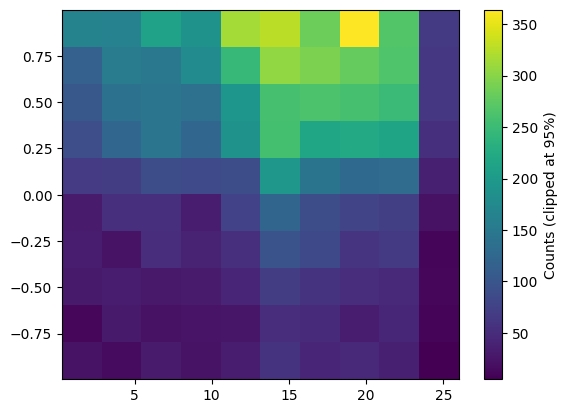

In [112]:
fig,ax = plt.subplots()
hist = F3LILT_gaze_ratio_hist
xedges = np.nanmean([F3LILT_050725['xedges'], F3LILT_050825['xedges'], F3LILT_050925['xedges'], F3LILT_051225['xedges'], F3LILT_051325['xedges']],axis=0)
yedges = np.nanmean([F3LILT_050725['yedges'], F3LILT_050825['yedges'], F3LILT_050925['yedges'], F3LILT_051225['yedges'], F3LILT_051325['yedges']],axis=0)
clip_value = np.percentile(hist, 100)
sc = ax.pcolormesh(xedges, yedges, np.clip(hist.T, 0, clip_value), 
                   cmap='viridis', shading='auto')
fig.colorbar(sc,label=f'Counts (clipped at {95}%)',ax=ax)


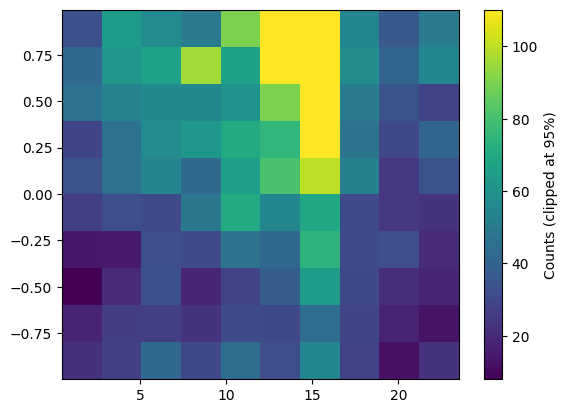

In [93]:
fig,ax = plt.subplots()
hist = F3LITT_gaze_ratio_hist
xedges = np.nanmean([F3LITT_050725['xedges'], F3LITT_050825['xedges'], F3LITT_050925['xedges'], F3LITT_051225['xedges'], F3LITT_051325['xedges']],axis=0)
yedges = np.nanmean([F3LITT_050725['yedges'], F3LITT_050825['yedges'], F3LITT_050925['yedges'], F3LITT_051225['yedges'], F3LITT_051325['yedges']],axis=0)
clip_value = np.percentile(hist, 95)
sc = ax.pcolormesh(xedges, yedges, np.clip(hist.T, 0, clip_value), 
                   cmap='viridis', shading='auto')
fig.colorbar(sc,label=f'Counts (clipped at {95}%)',ax=ax)


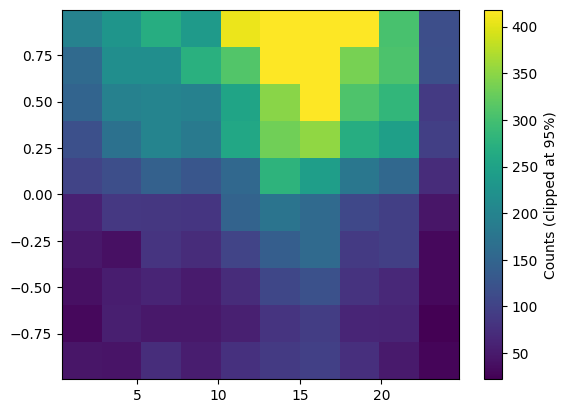

In [94]:
fig,ax = plt.subplots()
hist = F3LITT_gaze_ratio_hist +F3LILT_gaze_ratio_hist
xedges = np.nanmean([F3LITT_050725['xedges'], F3LITT_050825['xedges'], F3LITT_050925['xedges'], F3LITT_051225['xedges'], F3LITT_051325['xedges'],
                     F3LILT_050725['xedges'], F3LILT_050825['xedges'], F3LILT_050925['xedges'], F3LILT_051225['xedges'], F3LILT_051325['xedges']],axis=0)
yedges = np.nanmean([F3LITT_050725['yedges'], F3LITT_050825['yedges'], F3LITT_050925['yedges'], F3LITT_051225['yedges'], F3LITT_051325['yedges'],
                     F3LILT_050725['yedges'], F3LILT_050825['yedges'], F3LILT_050925['yedges'], F3LILT_051225['yedges'], F3LILT_051325['yedges']],axis=0)
clip_value = np.percentile(hist, 95)
sc = ax.pcolormesh(xedges, yedges, np.clip(hist.T, 0, clip_value), 
                   cmap='viridis', shading='auto')
fig.colorbar(sc,label=f'Counts (clipped at {95}%)',ax=ax)

In [113]:
F3LILT_050725_port = np.load(r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\F3LILT_050725_gaze_distance_port_ratio_histogram.npz")
F3LILT_050825_port = np.load(r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\F3LILT_050825_gaze_distance_port_ratio_histogram.npz")
F3LILT_050925_port = np.load(r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam\F3LILT_050925_gaze_distance_port_ratio_histogram.npz")
F3LILT_051225_port = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_gaze_distance_port_ratio_histogram.npz")
F3LILT_051325_port = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\F3LILT_051325_gaze_distance_port_ratio_histogram.npz")

F3LITT_050725_port = np.load(r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\F3LITT_050725_gaze_distance_port_ratio_histogram.npz")
F3LITT_050825_port = np.load(r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam\F3LITT_050825_gaze_distance_port_ratio_histogram.npz")
F3LITT_050925_port = np.load(r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam\F3LITT_050925_gaze_distance_port_ratio_histogram.npz")
F3LITT_051225_port = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\F3LITT_051225_gaze_distance_port_ratio_histogram.npz")
F3LITT_051325_port = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\F3LITT_051325_gaze_distance_port_ratio_histogram.npz")


In [114]:
F3LILT_gaze_ratio_port_hist = F3LILT_050725_port['hist']+ F3LILT_050825_port['hist']+ F3LILT_050925_port['hist']+ F3LILT_051225_port['hist']+ F3LILT_051325_port['hist']
F3LITT_gaze_ratio_port_hist = F3LITT_050725_port['hist']+ F3LITT_050825_port['hist']+ F3LITT_050925_port['hist']+ F3LITT_051225_port['hist']+ F3LITT_051325_port['hist']

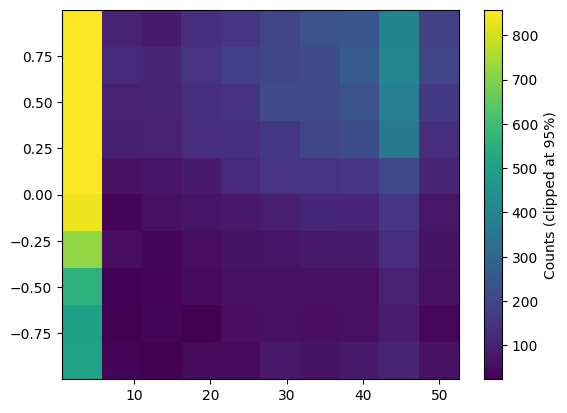

In [115]:
fig,ax = plt.subplots()
hist = F3LILT_gaze_ratio_port_hist +F3LITT_gaze_ratio_port_hist
xedges = np.nanmean([F3LITT_050725_port['xedges'], F3LITT_050825_port['xedges'], F3LITT_050925_port['xedges'], F3LITT_051225_port['xedges'], F3LITT_051325_port['xedges'],
                     F3LILT_050725_port['xedges'], F3LILT_050825_port['xedges'], F3LILT_050925_port['xedges'], F3LILT_051225_port['xedges'], F3LILT_051325_port['xedges']],axis=0)
yedges = np.nanmean([F3LITT_050725_port['yedges'], F3LITT_050825_port['yedges'], F3LITT_050925_port['yedges'], F3LITT_051225_port['yedges'], F3LITT_051325_port['yedges'],
                     F3LILT_050725_port['yedges'], F3LILT_050825_port['yedges'], F3LILT_050925_port['yedges'], F3LILT_051225_port['yedges'], F3LILT_051325_port['yedges']],axis=0)
clip_value = np.percentile(hist, 95)
sc = ax.pcolormesh(xedges, yedges, np.clip(hist.T, 0, clip_value), 
                   cmap='viridis', shading='auto')
fig.colorbar(sc,label=f'Counts (clipped at {95}%)',ax=ax)

In [ ]:
def plot_clipped_histogram(npz_path, cmap='viridis', clip_percentile=95):
    data = np.load(npz_path)
    hist = data['hist']
    xedges = data['xedges']
    yedges = data['yedges']
    
    # Determine clipping threshold
    clip_value = np.percentile(hist, clip_percentile)
    
    plt.pcolormesh(xedges, yedges, np.clip(hist.T, 0, clip_value), 
                   cmap=cmap, shading='auto')
    plt.colorbar(label=f'Counts (clipped at {clip_percentile}%)')
    plt.xlabel('Distance from edge')
    plt.ylabel('Eye/Head rotation ratio')
    plt.title(f'Clipped (P{clip_percentile}) Gaze Distance-Ratio')
    plt.show()

In [96]:
F3LILT_050725.files

['hist', 'xedges', 'yedges', 'dist_values', 'ratio_values']

(array([257.,  96., 181., 154., 139.,  88., 319., 185.,  38.,  20.]),
 array([ 0.83096577,  3.36564393,  5.90032209,  8.43500025, 10.96967841,
        13.50435657, 16.03903473, 18.57371289, 21.10839105, 23.64306921,
        26.17774738]),
 <BarContainer object of 10 artists>)

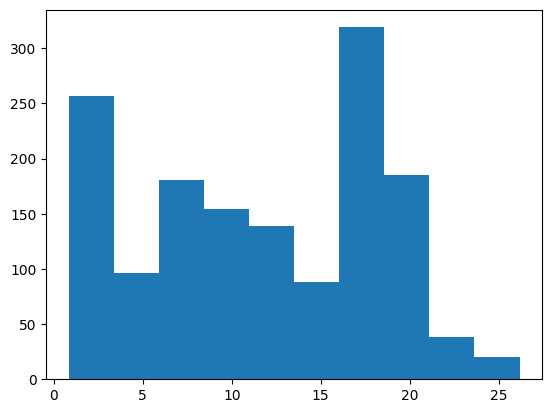

In [100]:
plt.hist(F3LILT_051225['dist_values'])

(array([1040., 1481., 1657., 1902., 2548., 3249., 2987.,  737.,  184.,
          20.]),
 array([ 0.03593913,  3.04930267,  6.06266621,  9.07602976, 12.0893933 ,
        15.10275684, 18.11612038, 21.12948392, 24.14284746, 27.15621101,
        30.16957455]),
 <BarContainer object of 10 artists>)

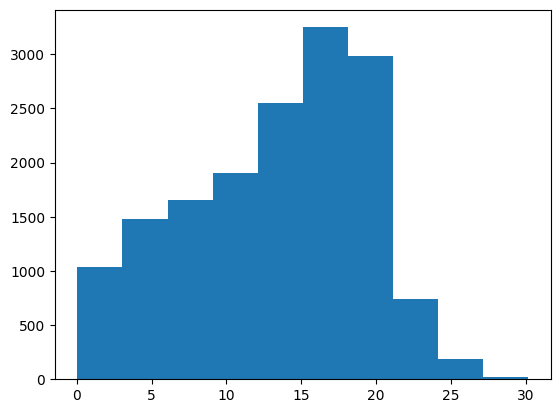

In [101]:
all_dist = np.concatenate([F3LITT_050725['dist_values'], F3LITT_050825['dist_values'], F3LITT_050925['dist_values'], F3LITT_051225['dist_values'], F3LITT_051325['dist_values'],
                     F3LILT_050725['dist_values'], F3LILT_050825['dist_values'], F3LILT_050925['dist_values'], F3LILT_051225['dist_values'], F3LILT_051325['dist_values']])
plt.hist(all_dist)

(array([316., 262., 275., 343., 414., 538., 593., 633., 752., 663.]),
 array([-0.99966637, -0.79979948, -0.5999326 , -0.40006571, -0.20019882,
        -0.00033194,  0.19953495,  0.39940184,  0.59926873,  0.79913561,
         0.9990025 ]),
 <BarContainer object of 10 artists>)

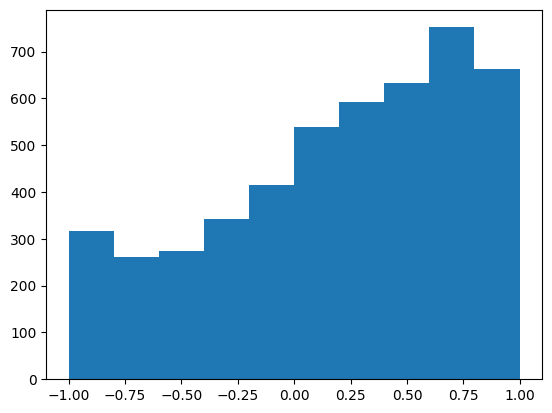

In [110]:
all_ratio = np.concatenate([F3LITT_050725['ratio_values'], F3LITT_050825['ratio_values'], F3LITT_050925['ratio_values'], F3LITT_051225['ratio_values'], F3LITT_051325['ratio_values']])
plt.hist(all_ratio)

(array([ 311.,  296.,  395.,  514.,  624., 1044., 1629., 1811., 2051.,
        2341.]),
 array([-0.99953243, -0.79958029, -0.59962815, -0.399676  , -0.19972386,
         0.00022829,  0.20018043,  0.40013257,  0.60008472,  0.80003686,
         0.99998901]),
 <BarContainer object of 10 artists>)

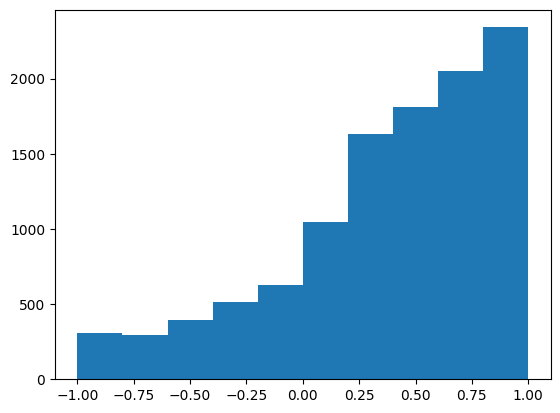

In [111]:
all_ratio = np.concatenate([F3LILT_050725['ratio_values'], F3LILT_050825['ratio_values'], F3LILT_050925['ratio_values'], F3LILT_051225['ratio_values'], F3LILT_051325['ratio_values']])
plt.hist(all_ratio)

(array([ 627.,  558.,  672.,  857., 1036., 1586., 2220., 2445., 2801.,
        3003.]),
 array([-0.99966637, -0.79970083, -0.5997353 , -0.39976976, -0.19980422,
         0.00016132,  0.20012686,  0.40009239,  0.60005793,  0.80002347,
         0.99998901]),
 <BarContainer object of 10 artists>)

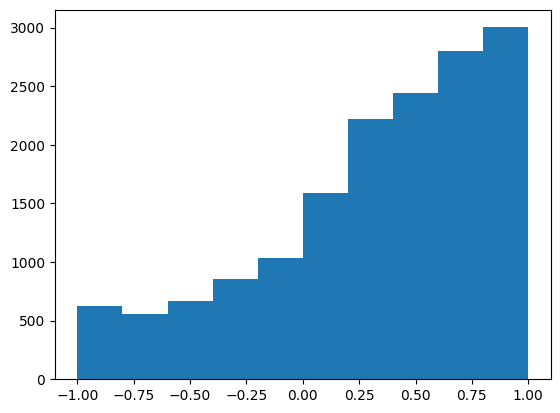

In [102]:
all_ratio = np.concatenate([F3LITT_050725['ratio_values'], F3LITT_050825['ratio_values'], F3LITT_050925['ratio_values'], F3LITT_051225['ratio_values'], F3LITT_051325['ratio_values'],
                     F3LILT_050725['ratio_values'], F3LILT_050825['ratio_values'], F3LILT_050925['ratio_values'], F3LILT_051225['ratio_values'], F3LILT_051325['ratio_values']])
plt.hist(all_ratio)

In [108]:
len(F3LITT_050725_imu['gazeL_event']) + len(F3LITT_050725_imu['gazeR_event'])

1828

In [106]:
len(F3LITT_051325_imu['compL_event']) + len(F3LITT_051325_imu['compR_event'])

14644

In [109]:
len(F3LITT_050725_imu['compL_event']) + len(F3LITT_050725_imu['compR_event'])

15856